In [1]:
import numpy as np
import pandas as pd
import matplotlib
print(matplotlib.__version__)
matplotlib.use('PDF')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.lines as mlines
from glob import glob
from collections import Counter
#import ns
import history_cmc as hic
import math
import scipy
from scipy.interpolate import interp1d
from scipy import stats
import matplotlib.cm as cm
import matplotlib as mpl
import random
from random import shuffle
import gzip
import sys
import astropy
from astropy import units
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
print('done')

#import gw_ecc_calc as gwcalc
#import unit_convert as uc
#import merger_rate_calculator as mr
#import ns_tidalcapture as tc
import conversions
import dynamics as dyn
print('done')

%matplotlib inline

matplotlib.rcParams.update({'font.size': 24})

sys.path.insert(1, '/fs/lustre/cita/claireshiye/cmctoolkit')
import cmctoolkit as cmct
      
twopi=2.*np.pi
yearsc=3.1557*10**7
Kconst=9.87*10**-48 ##yr/G^2
Gconst=6.674*10**-8 ##cm3*g-1*s-2
Gconst_sun = 4.30091*10**-3 ##pc*M_sun**-1*(km/s)^2
clight=3*10**10 ##cm/s
Msun=2*10**33 ##gram
AU=1.496*10**13  ##cm
AU_Rsun=214.93946938362 ##AU to R_sun
PC=3.086*10**18  ##cm
PC_Rsun = 44334448.0068964 ##pc to R_sun

3.5.2
done
done


13.800170986392


/fs/lustre/cita/claireshiye/cmctoolkit/cmctoolkit.py:1099: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.filtertable = self.filtertable.append(filterrow, ignore_index=True)
/fs/lustre/cita/claireshiye/cmctoolkit/cmctoolkit.py:1099: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.filtertable = self.filtertable.append(filterrow, ignore_index=True)
/fs/lustre/cita/claireshiye/cmctoolkit/cmctoolkit.py:1099: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.filtertable = self.filtertable.append(filterrow, ignore_index=True)
/fs/lustre/cita/claireshiye/cmctoolkit/cmctoolkit.py:1099: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.

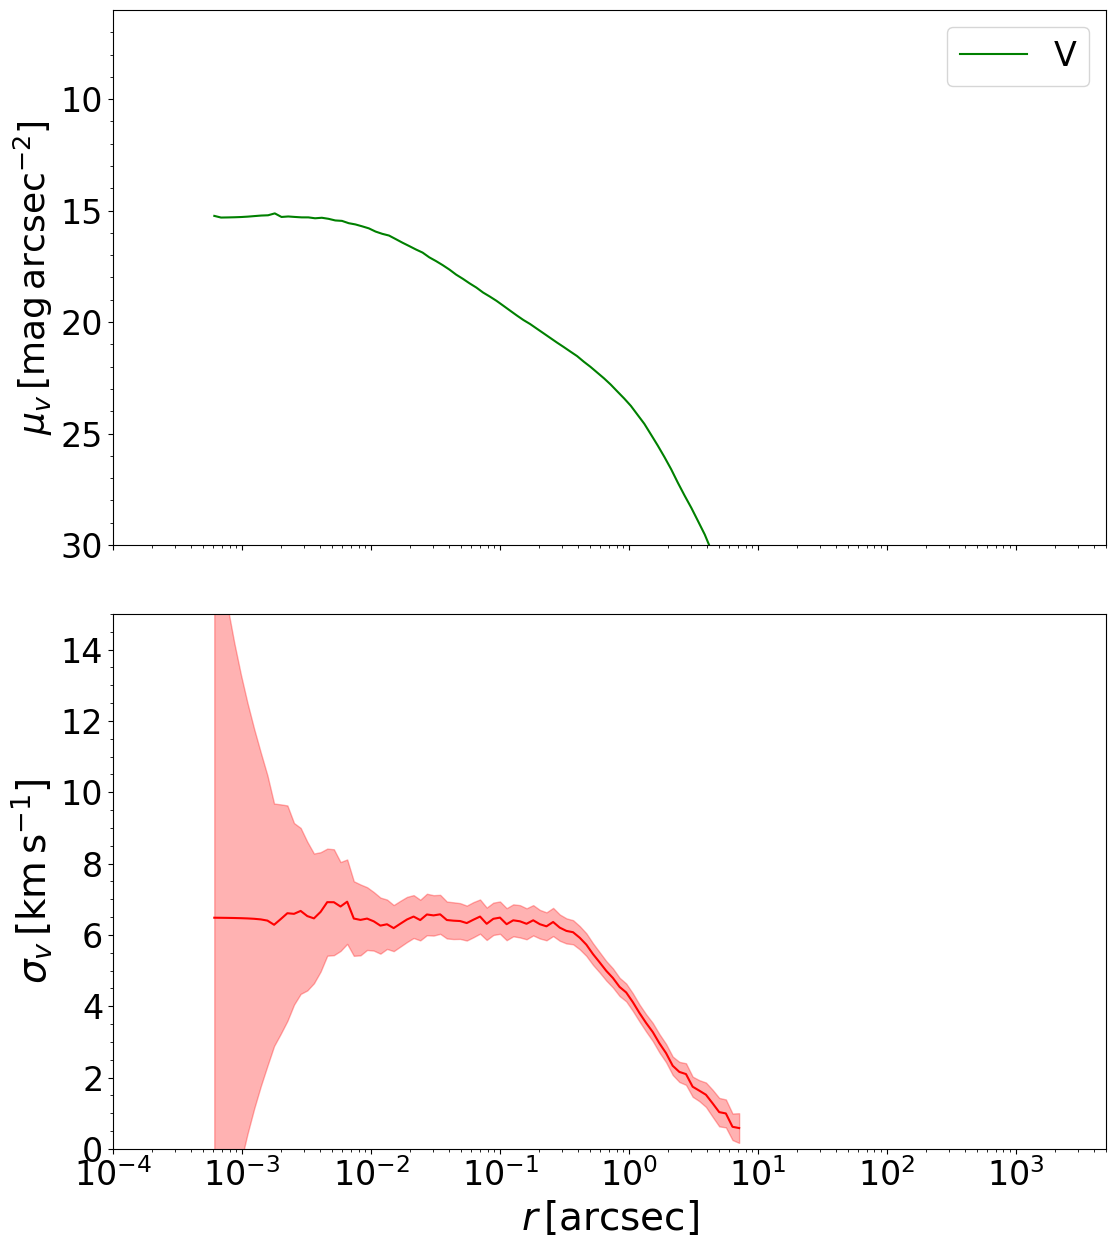

In [6]:
path = '/fs/lustre/cita/claireshiye/CMC-COSMIC/CMC/M81host/N1.6e6_rv5_rg20_z0.002_w9_toplightIMF/'
snap_h5 = 'initial11.snapshots.h5'

snap = cmct.Snapshot(fname=path+snap_h5, snapshot_name='/538(t=0.43317213)', conv=path+'initial.conv.sh', 
                     dist=3600, # distance to cluster in kpc
                     z=0.002)
print(snap.age)
##First Check
Rsun = 3600

###############################################
##Make surface brightness profile
snap.add_photometry('/fs/lustre/cita/claireshiye/cmctoolkit/filt_index.txt')
v_bincenter, v_profile = snap.make_smoothed_brightness_profile('V', bins=80,
                                                               min_mass=None, max_mass=None,
                                                               max_lum=15, fluxdict=None,
                                                               startypes=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                                               min_logr=-2.0)


# Make velocity dispersion profiles
star_velbin_center, star_veldisp_profile, star_e_veldisp_profile = snap.make_smoothed_veldisp_profile(bins=80,
                                                                 min_mass=None,
                                                                 max_mass=None,
                                                                 dmax=None,
                                                                 fluxdict=None,
                                                                 startypes=np.array([2, 3, 4, 5, 6, 7, 8, 9]),
                                                                 min_logr=-2.0)

star_velbin_arcsec = conversions.pc_to_arcsec(star_velbin_center,Rsun)


fig, ax=plt.subplots(2, 1, sharex=True,  figsize=(12,13))
#ax[0].set_title(r'$\rm{NGC}\ $'+ngcno, fontsize=20)
ax[0].plot(v_bincenter, v_profile, c='g', label='V')

ax[1].plot(star_velbin_arcsec, star_veldisp_profile, c='r', label='Stars')
ax[1].fill_between(star_velbin_arcsec, star_veldisp_profile - star_e_veldisp_profile,
                                  star_veldisp_profile + star_e_veldisp_profile, color='r', alpha=0.3)


ax[0].yaxis.set_minor_locator(AutoMinorLocator())
ax[0].set_ylim(30,6)
ax[0].set_xscale('log')
ax[0].set_xlim(0.01,5000)
ax[0].set_ylabel(r'$\mu_v\,[\rm{mag\,arcsec^{-2}}]$',fontsize=26)
ax[0].legend(loc='best',scatterpoints=1, ncol=2, prop={'size': 24})

ax[1].yaxis.set_minor_locator(AutoMinorLocator())
ax[1].set_xscale('log')
ax[1].set_xlim(xmin=0.0001)
ax[1].set_ylim(0, 15)
ax[1].set_xlabel(r'$r\,[\rm{arcsec}]$',fontsize=28)
ax[1].set_ylabel(r'$\sigma_v\,[\rm{km\,s^{-1}}]$',fontsize=28)
#ax[1].legend(loc=3,scatterpoints=1, ncol=2, prop={'size': 24})

plt.subplots_adjust(hspace=0.05)
fig.tight_layout()

In [ ]:
###Checking for AIC

